In [10]:
# ==============================================================================
# CELL 1: DATA PREPARATION & ADVANCED TUNING WITH OPTUNA
# ==============================================================================

import pandas as pd
import numpy as np
import warnings
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

# 1. Load the dataset
df = pd.read_csv('Bank_Churn.csv')

# 2. Advanced Feature Engineering Function
def perform_advanced_features(data):
    df_copy = data.copy()
    df_copy['Balance_Salary_Ratio'] = df_copy['Balance'] / (df_copy['EstimatedSalary'] + 1)
    df_copy['Is_Balance_Zero'] = (df_copy['Balance'] == 0).astype(int)
    df_copy['Tenure_Age_Ratio'] = df_copy['Tenure'] / df_copy['Age']
    df_copy['Products_Per_Active'] = df_copy['NumOfProducts'] * df_copy['IsActiveMember']
    df_copy['Age_Group'] = pd.cut(df_copy['Age'], 
                                  bins=[0, 30, 45, 60, 100], 
                                  labels=['Young', 'Middle-Aged', 'Senior', 'Elderly'])
    return df_copy

df_enhanced = perform_advanced_features(df)

# 3. Data Splitting
X = df_enhanced.drop(columns=['CustomerId', 'Surname', 'Exited'])
y = df_enhanced['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Building the Preprocessor Pipeline
numerical_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'Balance_Salary_Ratio', 'Is_Balance_Zero', 'Tenure_Age_Ratio', 'Products_Per_Active'
]
categorical_cols = ['Geography', 'Gender', 'Age_Group']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# 5. Define the Objective Function for Optuna
def objective(trial):
    # Search space definition
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 64),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'is_unbalance': True,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    trial_model = LGBMClassifier(**params)
    temp_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', trial_model)])
    
    temp_pipeline.fit(X_train, y_train)
    preds_proba = temp_pipeline.predict_proba(X_test)[:, 1]
    
    return roc_auc_score(y_test, preds_proba)

# 6. Run the Optimization
print("Starting Optuna optimization safely...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("\n[SUCCESS] Optimization Complete!")
print("Best Trial ROC-AUC:", study.best_value)
print("Best Parameters found:", study.best_params)

[I 2026-05-29 20:23:18,240] A new study created in memory with name: no-name-bf056918-baba-4d1c-8a25-1b5494117038


Starting Optuna optimization safely...


[I 2026-05-29 20:23:19,567] Trial 0 finished with value: 0.835715530630785 and parameters: {'n_estimators': 292, 'max_depth': 7, 'num_leaves': 57, 'learning_rate': 0.09377846408902085, 'min_child_samples': 42}. Best is trial 0 with value: 0.835715530630785.
[I 2026-05-29 20:23:21,023] Trial 1 finished with value: 0.8545201596049052 and parameters: {'n_estimators': 184, 'max_depth': 9, 'num_leaves': 64, 'learning_rate': 0.03165669853880544, 'min_child_samples': 28}. Best is trial 1 with value: 0.8545201596049052.
[I 2026-05-29 20:23:22,094] Trial 2 finished with value: 0.8263039618971824 and parameters: {'n_estimators': 284, 'max_depth': 9, 'num_leaves': 53, 'learning_rate': 0.14476572672037955, 'min_child_samples': 41}. Best is trial 1 with value: 0.8545201596049052.
[I 2026-05-29 20:23:23,192] Trial 3 finished with value: 0.8583807227875024 and parameters: {'n_estimators': 252, 'max_depth': 10, 'num_leaves': 52, 'learning_rate': 0.017813410178609466, 'min_child_samples': 38}. Best is 


[SUCCESS] Optimization Complete!
Best Trial ROC-AUC: 0.872414787669025
Best Parameters found: {'n_estimators': 106, 'max_depth': 5, 'num_leaves': 36, 'learning_rate': 0.056517528640122654, 'min_child_samples': 11}


Training the final optimized production model... Please wait.
Production model training completed successfully!

=================== PRODUCTION MODEL REPORT ===================
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      1593
           1       0.52      0.76      0.62       407

    accuracy                           0.81      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.85      0.81      0.82      2000

Optimized Production ROC-AUC: 0.8724



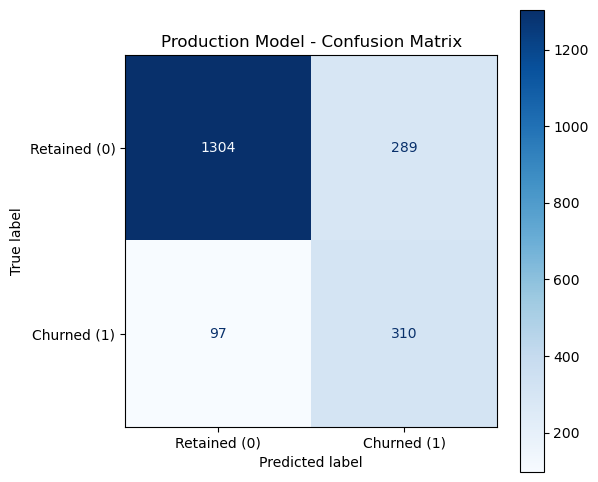

In [11]:
# ==============================================================================
# CELL 2: TRAINING THE OPTIMIZED PRODUCTION MODEL
# ==============================================================================

import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# 1. Re-build LightGBM using the optimal parameters found by Optuna
best_params = study.best_params
best_params['is_unbalance'] = True
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1

optimized_lgb = LGBMClassifier(**best_params)

# 2. Final production pipeline assembly
production_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', optimized_lgb)
])

# 3. Train on the training set
print("Training the final optimized production model... Please wait.")
production_pipeline.fit(X_train, y_train)
print("Production model training completed successfully!\n")

# 4. Final predictions and probabilities
y_pred_prod = production_pipeline.predict(X_test)
y_pred_proba_prod = production_pipeline.predict_proba(X_test)[:, 1]

# 5. Display the professional performance metrics
print("=================== PRODUCTION MODEL REPORT ===================")
print(classification_report(y_test, y_pred_prod))
print(f"Optimized Production ROC-AUC: {roc_auc_score(y_test, y_pred_proba_prod):.4f}")
print("===============================================================\n")

# 6. Plot final clean confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
cm_prod = confusion_matrix(y_test, y_pred_prod)
disp_prod = ConfusionMatrixDisplay(confusion_matrix=cm_prod, display_labels=['Retained (0)', 'Churned (1)'])

disp_prod.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Production Model - Confusion Matrix')
plt.grid(False)
plt.show()

Generating SHAP Summary Plot for Model Interpretability...


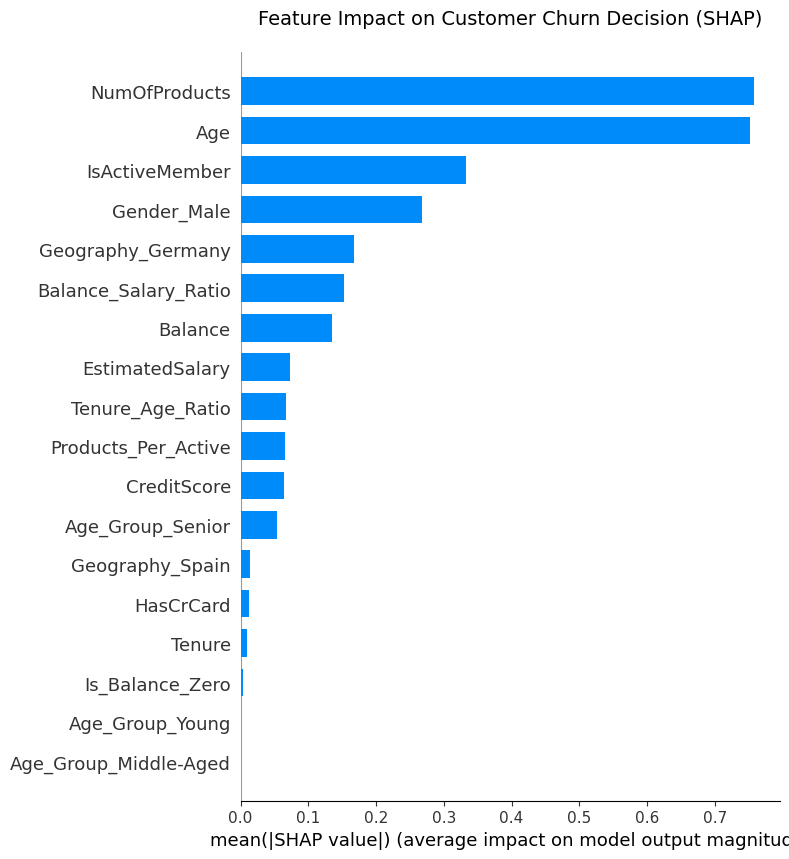

In [12]:
# ==============================================================================
# CELL 3: EXPLAINABLE AI (SHAP VISUALIZATION)
# ==============================================================================

import shap
import matplotlib.pyplot as plt

# 1. Extract feature names correctly after transformation
cat_encoder = production_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_cols = list(cat_encoder.get_feature_names_out(categorical_cols))
feature_names = numerical_cols + encoded_cat_cols

# 2. Transform the test features to match model input shape
X_test_transformed = production_pipeline.named_steps['preprocessor'].transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# 3. Initialize SHAP TreeExplainer using our optimized LightGBM model
model_step = production_pipeline.named_steps['model']
explainer = shap.TreeExplainer(model_step)
shap_values = explainer.shap_values(X_test_transformed)

# 4. Handle shap values output format safely for LightGBM
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
else:
    shap_vals_to_plot = shap_values

# 5. Plot global feature importance based on SHAP values
print("Generating SHAP Summary Plot for Model Interpretability...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_plot, X_test_transformed, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Feature Impact on Customer Churn Decision (SHAP)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

Training the Tuned Ultimate Voting Ensemble... Please wait.
Ultimate Ensemble trained successfully!

=================== TUNED ULTIMATE ENSEMBLE REPORT ===================
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1593
           1       0.56      0.72      0.63       407

    accuracy                           0.83      2000
   macro avg       0.74      0.79      0.76      2000
weighted avg       0.85      0.83      0.84      2000

Final Tuned Ensemble ROC-AUC: 0.8714



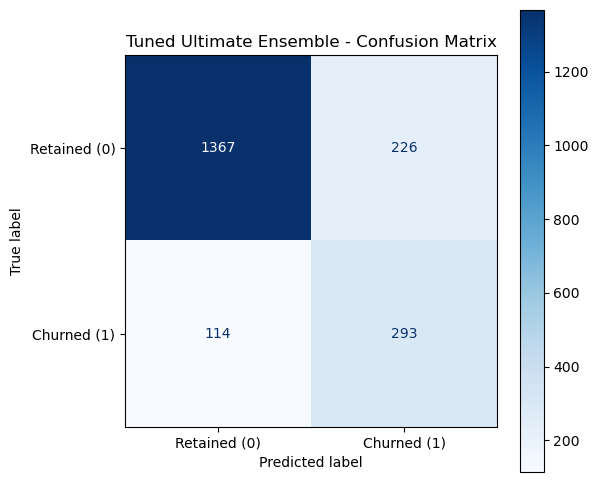

In [14]:
# ==============================================================================
# FINAL CELL: THE ULTIMATE ENSEMBLE (TUNED LIGHTGBM + XGBOOST + RANDOM FOREST)
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# 1. Recalculate imbalance ratio safely inside the cell to prevent NameError
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Get the best parameters found by Optuna for LightGBM
lgb_best_params = study.best_params.copy()  # Using .copy() is safer
lgb_best_params['is_unbalance'] = True
lgb_best_params['random_state'] = 42
lgb_best_params['n_jobs'] = -1
lgb_best_params['verbose'] = -1

# 3. Define the 3 powerhouses
tuned_lgb = LGBMClassifier(**lgb_best_params)

xgb_base = XGBClassifier(
    n_estimators=150, 
    max_depth=5, 
    learning_rate=0.05, 
    scale_pos_weight=imbalance_ratio, 
    random_state=42, 
    eval_metric='logloss', 
    n_jobs=-1
)

rf_base = RandomForestClassifier(
    n_estimators=150, 
    max_depth=12, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

# 4. Build the Ultimate Voting Classifier (Soft Voting)
ultimate_voting_ensemble = VotingClassifier(
    estimators=[
        ('tuned_lgbm', tuned_lgb),
        ('xgb', xgb_base),
        ('rf', rf_base)
    ],
    voting='soft',
    n_jobs=-1
)

# 5. Create the final production pipeline
ultimate_ensemble_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ensemble', ultimate_voting_ensemble)
])

# 6. Train the ultimate ensemble
print("Training the Tuned Ultimate Voting Ensemble... Please wait.")
ultimate_ensemble_pipeline.fit(X_train, y_train)
print("Ultimate Ensemble trained successfully!\n")

# 7. Make final predictions
y_pred_final = ultimate_ensemble_pipeline.predict(X_test)
y_pred_proba_final = ultimate_ensemble_pipeline.predict_proba(X_test)[:, 1]

# 8. Print the final professional performance report
print("=================== TUNED ULTIMATE ENSEMBLE REPORT ===================")
print(classification_report(y_test, y_pred_final))
print(f"Final Tuned Ensemble ROC-AUC: {roc_auc_score(y_test, y_pred_proba_final):.4f}")
print("======================================================================\n")

# 9. Plot the final confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
cm_final = confusion_matrix(y_test, y_pred_final)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Retained (0)', 'Churned (1)'])

disp_final.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Tuned Ultimate Ensemble - Confusion Matrix')
plt.grid(False)
plt.show()